<a href="https://colab.research.google.com/github/szabeebzaliz7-a11y/Datascience-And-Gen-AI/blob/main/Statistics_Module_End_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Statistics Project

To analyze customer behavior using statistical and mathematical tools in Python, to
identify factors affecting customer retention and churn.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
df=pd.read_csv('customer_behavior.csv')

In [7]:
df

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
...,...,...,...,...,...,...,...
4995,5996,Female,West,1497.00,Electronics,Yes,B
4996,5997,Male,West,978.87,Fashion,Yes,A
4997,5998,Male,West,906.93,Fashion,No,NaN
4998,5999,Female,South,375.67,Fashion,No,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5000 non-null   int64  
 1   Gender           4903 non-null   object 
 2   Region           4825 non-null   object 
 3   PurchaseAmount   4850 non-null   float64
 4   ProductCategory  4474 non-null   object 
 5   Churn            4735 non-null   object 
 6   CampaignGroup    4815 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 273.6+ KB


1. What is the average, median, and mode of PurchaseAmount?

In [9]:
mean=df['PurchaseAmount'].mean()
median=df['PurchaseAmount'].median()
mode=df['PurchaseAmount'].mode()
print('mean:',mean)
print('median:',median)
print('mode:',mode)

mean: 1003.9506701030928
median: 998.0799999999999
mode: 0    0.0
Name: PurchaseAmount, dtype: float64


2. Are there any outliers in the PurchaseAmount data?

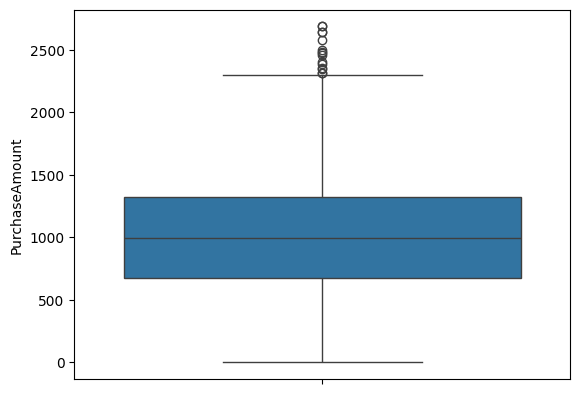

In [10]:
sns.boxplot(df['PurchaseAmount'])
plt.show()

In [11]:
q1=df['PurchaseAmount'].quantile(0.25)
q3=df['PurchaseAmount'].quantile(0.75)
# q1
# q3
iqr=q3-q1
# iqr
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
print(lower_bound,upper_bound)
outliers=df[(df['PurchaseAmount']<lower_bound) | (df['PurchaseAmount']>upper_bound)]
print(outliers)

-306.51000000000033 2307.2300000000005
      CustomerID  Gender Region  PurchaseAmount ProductCategory Churn  \
195         1196    Male   West         2318.33         Fashion   Yes   
265         1266  Female   East         2496.41     Electronics   Yes   
348         1349    Male  South         2688.69     Electronics   Yes   
411         1412  Female  South         2349.16         Fashion   Yes   
826         1827    Male   East         2578.89     Electronics   Yes   
1358        2359    Male   West         2384.19     Electronics   Yes   
2285        3286    Male   East         2457.05         Grocery    No   
2557        3558    Male   East         2316.19         Fashion   Yes   
2681        3682  Female   East         2400.69         Fashion   Yes   
3326        4327  Female  North         2357.41         Grocery    No   
3438        4439  Female   East         2688.88         Grocery    No   
3564        4565    Male   East         2643.88     Electronics   Yes   
4345        

3. Is there any skewness or kurtosis in the PurchaseAmount distribution?

<Axes: xlabel='PurchaseAmount', ylabel='Count'>

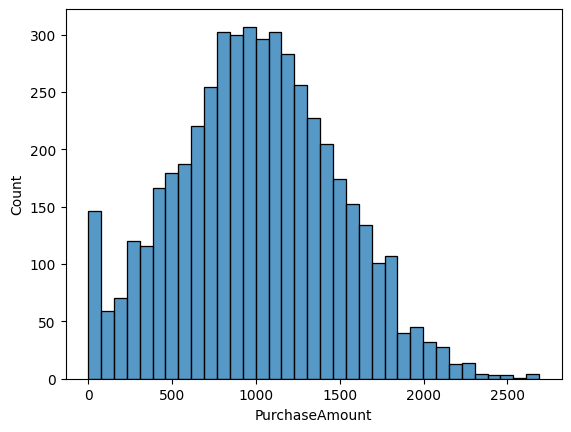

In [12]:
sns.histplot(df['PurchaseAmount'])

In [13]:
skewness = df['PurchaseAmount'].skew()
kurtosis = df['PurchaseAmount'].kurt()
print(f"Skewness: {skewness}")
print(f"Kurtosis: {kurtosis}")

Skewness: 0.10609189374631554
Kurtosis: -0.2615105545319705


4. Is there a significant difference in spending between male and female
customers?

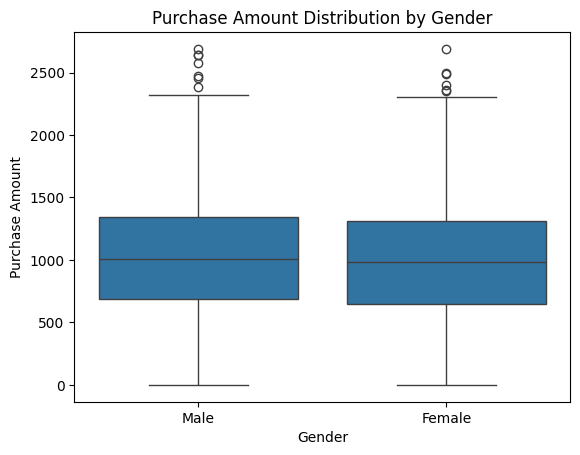

In [14]:
sns.boxplot(x='Gender', y='PurchaseAmount', data=df)
plt.title('Purchase Amount Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Purchase Amount')
plt.show()

In [15]:
gender_spending = df.groupby('Gender')['PurchaseAmount'].agg(['mean', 'median', 'std', 'count']).reset_index()
print("Descriptive statistics of PurchaseAmount by Gender:")
display(gender_spending)

Descriptive statistics of PurchaseAmount by Gender:


,Gender,mean,median,std,count
0,Female,987.872046,983.000,485.763793,2370
1,Male,1019.176609,1011.215,480.225125,2386


In [16]:
from scipy import stats

male_spending = df[df['Gender'] == 'Male']['PurchaseAmount'].dropna()
female_spending = df[df['Gender'] == 'Female']['PurchaseAmount'].dropna()

# Perform independent t-test
t_stat, p_value = stats.ttest_ind(male_spending, female_spending)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.3f}")

alpha = 0.05 # Significance level

if p_value < alpha:
    print("There is a statistically significant difference in PurchaseAmount between male and female customers.")
else:
    print("There is no statistically significant difference in PurchaseAmount between male and female customers.")

T-statistic: 2.23
P-value: 0.025
There is a statistically significant difference in PurchaseAmount between male and female customers.


5. Is there a relationship between ProductCategory and customer churn?

In [17]:
df_cleaned = df.dropna(subset=['ProductCategory', 'Churn'])
print("Shape of original DataFrame:", df.shape)
print("Shape of cleaned DataFrame:", df_cleaned.shape)
print("Missing values after cleaning:")
print(df_cleaned[['ProductCategory', 'Churn']].isnull().sum())

Shape of original DataFrame: (5000, 7)
Shape of cleaned DataFrame: (4231, 7)
Missing values after cleaning:
ProductCategory    0
Churn              0
dtype: int64


In [18]:
chi2=pd.crosstab(df_cleaned['ProductCategory'],df_cleaned['Churn'])
chi2

Churn,No,Yes
ProductCategory,,
Electronics,785,541
Fashion,839,607
Grocery,855,604


6. Does PurchaseAmount vary significantly across different regions?

In [19]:
purchase_amount_by_region = df.groupby('Region')['PurchaseAmount'].mean()
purchase_amount_by_region

,PurchaseAmount
Region,
East,1009.946017
North,1013.017952
South,997.603877
West,995.247327


7. Which email campaign (A or B) performed better in terms of average
PurchaseAmount?

In [20]:
campaign_performance = df.groupby('CampaignGroup')['PurchaseAmount'].mean().reset_index()
print("Average PurchaseAmount by CampaignGroup:")
display(campaign_performance)

better_campaign = campaign_performance.loc[campaign_performance['PurchaseAmount'].idxmax()]
print(f"\nCampaign '{better_campaign['CampaignGroup']}' performed better with an average PurchaseAmount of {better_campaign['PurchaseAmount']:.2f}.")

Average PurchaseAmount by CampaignGroup:


,CampaignGroup,PurchaseAmount
0,A,1011.945587
1,B,994.339965



Campaign 'A' performed better with an average PurchaseAmount of 1011.95.


8. Can we assume PurchaseAmount follows a normal distribution?

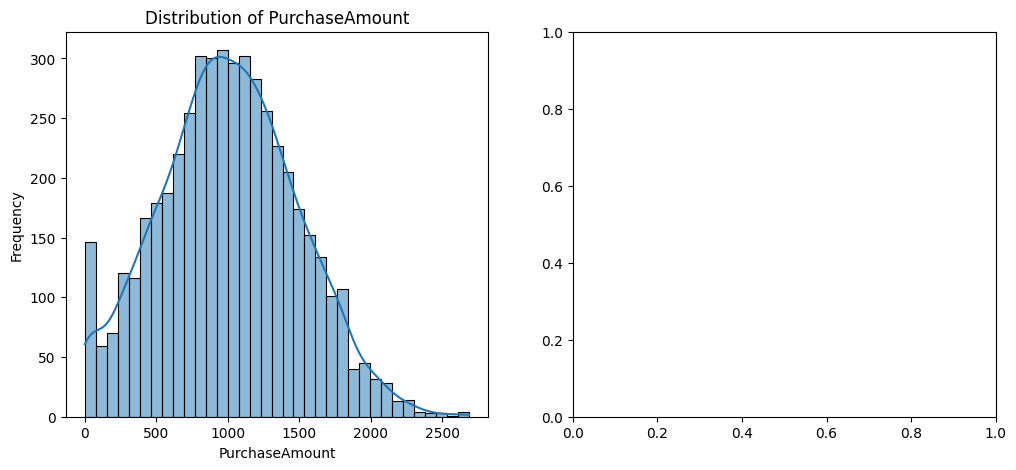

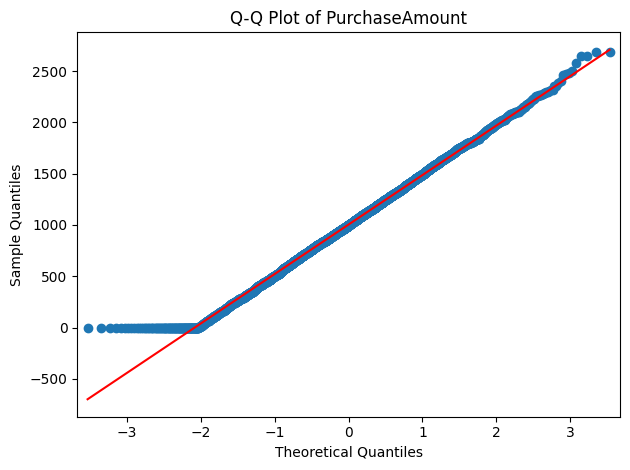

In [21]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['PurchaseAmount'].dropna(), kde=True)
plt.title('Distribution of PurchaseAmount')
plt.xlabel('PurchaseAmount')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
import statsmodels.api as sm
sm.qqplot(df['PurchaseAmount'].dropna(), line='s')
plt.title('Q-Q Plot of PurchaseAmount')

plt.tight_layout()
plt.show()

In [23]:
from scipy.stats import shapiro

purchase_amount_cleaned = df['PurchaseAmount'].dropna()
stat, p = shapiro(purchase_amount_cleaned)
print(f'Shapiro-Wilk Test Statistic: {stat:.3f}')
print(f'Shapiro-Wilk Test P-value: {p:.3f}')

alpha = 0.05
if p > alpha:
    print('Sample looks Gaussian (fail to reject H0)')
else:
    print('Sample does not look Gaussian (reject H0)')

Shapiro-Wilk Test Statistic: 0.995
Shapiro-Wilk Test P-value: 0.000
Sample does not look Gaussian (reject H0)


9. What insights can we gain by applying the Central Limit Theorem?

Reliable Inference for Means: Even though individual PurchaseAmounts aren't normal, if we were to take multiple samples of customer purchase amounts and calculate the mean for each sample, the distribution of these sample means would tend to be normal. This is crucial because it allows us to use parametric statistical tests (which often assume normality) to make inferences about the population mean purchase amount based on sample means, even when the individual data points are not normally distributed.

Hypothesis Testing: This enables us to perform hypothesis tests (like t-tests, for example, if comparing mean purchase amounts between groups) more reliably, as the sampling distribution of the test statistic would approach normality under the null hypothesis.

Confidence Intervals: We can construct confidence intervals for the true population mean PurchaseAmount with greater confidence, as the CLT ensures the sampling distribution used for these calculations is approximately normal.


10.What is the 95% confidence interval for the average PurchaseAmount?

In [24]:
from scipy import stats
import numpy as np

purchase_amount = df['PurchaseAmount'].dropna()

mean_purchase_amount = purchase_amount.mean()
std_err_purchase_amount = stats.sem(purchase_amount) # Standard error of the mean
n = len(purchase_amount)

# For a 95% confidence interval, alpha = 0.05, and alpha/2 = 0.025
# Degrees of freedom (df) = n - 1
confidence_level = 0.95
df_ci = n - 1

# Calculate the margin of error using the t-distribution
margin_of_error = stats.t.ppf((1 + confidence_level) / 2, df_ci) * std_err_purchase_amount

lower_bound_ci = mean_purchase_amount - margin_of_error
upper_bound_ci = mean_purchase_amount + margin_of_error

print(f"Average PurchaseAmount: {mean_purchase_amount:.2f}")
print(f"95% Confidence Interval for Average PurchaseAmount: ({lower_bound_ci:.2f}, {upper_bound_ci:.2f})")

Average PurchaseAmount: 1003.95
95% Confidence Interval for Average PurchaseAmount: (990.38, 1017.52)
